# ✈️ Sentiment Analysis on Airline Tweets

**Oasis Infobyte — Data Analytics Internship | Task 4**

---

I built this project to explore how well classical machine learning models handle sentiment classification on airline tweets. The dataset has ~3,000 labeled tweets, and I train three different models to see which one works best.

We'll go through everything from loading the data, cleaning the text, building features with TF-IDF, training models, and looking at where things go wrong.

Let's dive in.

## 1. Importing Libraries

Here's everything we need. Standard data science tools plus a couple NLP-specific ones.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string, re

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('All libraries loaded.')

All libraries loaded.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Loading the Dataset

The dataset contains airline tweets from February 2015. Each row has the tweet text, the airline mentioned, and the sentiment label. We'll load it and check the basics — shape, columns, and a few sample rows.

In [2]:
df = pd.read_csv('dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nData types:\n{df.dtypes}')

print('\nFirst five rows:')
display(df.head())

print('\nLast five rows:')
display(df.tail())

Shape: (3000, 15)
Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Data types:
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold          float64
name                             object
negativereason_gold             float64
retweet_count                     int64
text                             object
tweet_coord                     float64
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

First five rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,1000,positive,0.90,NaN,0.00,United,NaN,User4468,NaN,28,Amazing flight crew! So friendly and attentive...,NaN,2015-03-08 23:06:00,Boston,NaN
1,1001,positive,0.64,NaN,0.00,United,NaN,User1629,NaN,64,Amazing flight crew! So friendly and attentive...,NaN,2015-07-05 00:35:00,Seattle,Central Time
2,1002,positive,0.92,NaN,0.00,American,NaN,User2788,NaN,97,Flying with @Delta today and everything was pe...,NaN,2015-03-13 22:27:00,LA,Central Time
3,1003,negative,0.73,Customer service issue,0.69,Virgin America,NaN,User356,NaN,44,@AlaskaAir my miles expired without warning. N...,NaN,2015-07-05 08:51:00,Miami,NaN
4,1004,negative,0.63,Bad flight,0.91,Virgin America,NaN,User376,NaN,73,@JetBlue your WiFi never works. Paying for int...,NaN,2015-03-22 22:04:00,Chicago,Pacific Time



Last five rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
2995,3995,negative,0.62,Canceled flight,0.57,JetBlue,NaN,User4058,NaN,33,@AlaskaAir my miles expired without warning. N...,NaN,2015-03-12 11:39:00,NYC,Eastern Time
2996,3996,negative,0.72,Canceled flight,0.91,Alaska,NaN,User1155,NaN,70,@United had to sleep in the airport because of...,NaN,2015-02-27 22:39:00,Boston,Pacific Time
2997,3997,positive,0.70,NaN,0.00,US Airways,NaN,User2415,NaN,57,@SouthwestAir no fees for bags? Yes please! Be...,NaN,2015-04-20 12:00:00,NYC,NaN
2998,3998,negative,0.98,Damaged luggage,0.86,US Airways,NaN,User2149,NaN,87,@AmericanAir 2 hour delay and counting. No upd...,NaN,2015-06-02 05:05:00,Seattle,Eastern Time
2999,3999,positive,0.73,NaN,0.00,American,NaN,User1483,NaN,34,@Delta flight delay but your customer service ...,NaN,2015-04-30 04:39:00,Seattle,Mountain Time


### Quick notes

The dataset has 15 columns, but we mostly care about two: `text` (the tweet) and `airline_sentiment` (the label).

The sentiment column has three classes:
- **positive** — good experience
- **negative** — something went wrong
- **neutral** — no strong emotion

Everything else is metadata we can ignore for modeling.

## 3. Exploratory Data Analysis

Before cleaning the text, let's understand what we're working with. Checking missing values, duplicates, and how the sentiments are distributed.

In [3]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Missing values per column:')
print(missing)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f'\nDuplicate rows: {duplicates}')

# Basic statistics
print(f'\nSentiment distribution (raw counts):\n{df["airline_sentiment"].value_counts()}')
print(f'\nSentiment distribution (percentages):')
print((df['airline_sentiment'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

# Airline distribution
print(f'\nAirlines represented:\n{df["airline"].value_counts()}')


Missing values per column:
airline_sentiment_gold    3000
negativereason_gold       3000
tweet_coord               3000
negativereason            1983
user_timezone              587
tweet_location             409
dtype: int64

Duplicate rows: 0

Sentiment distribution (raw counts):
airline_sentiment
neutral     1037
negative    1017
positive     946
Name: count, dtype: int64

Sentiment distribution (percentages):
airline_sentiment
neutral     34.6%
negative    33.9%
positive    31.5%
Name: proportion, dtype: object

Airlines represented:
airline
JetBlue           407
Delta             392
American          375
Alaska            373
United            370
US Airways        366
Southwest         362
Virgin America    355
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30952\1500589225.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', order=sentiment_order, ax=axes[0], palette='viridis')


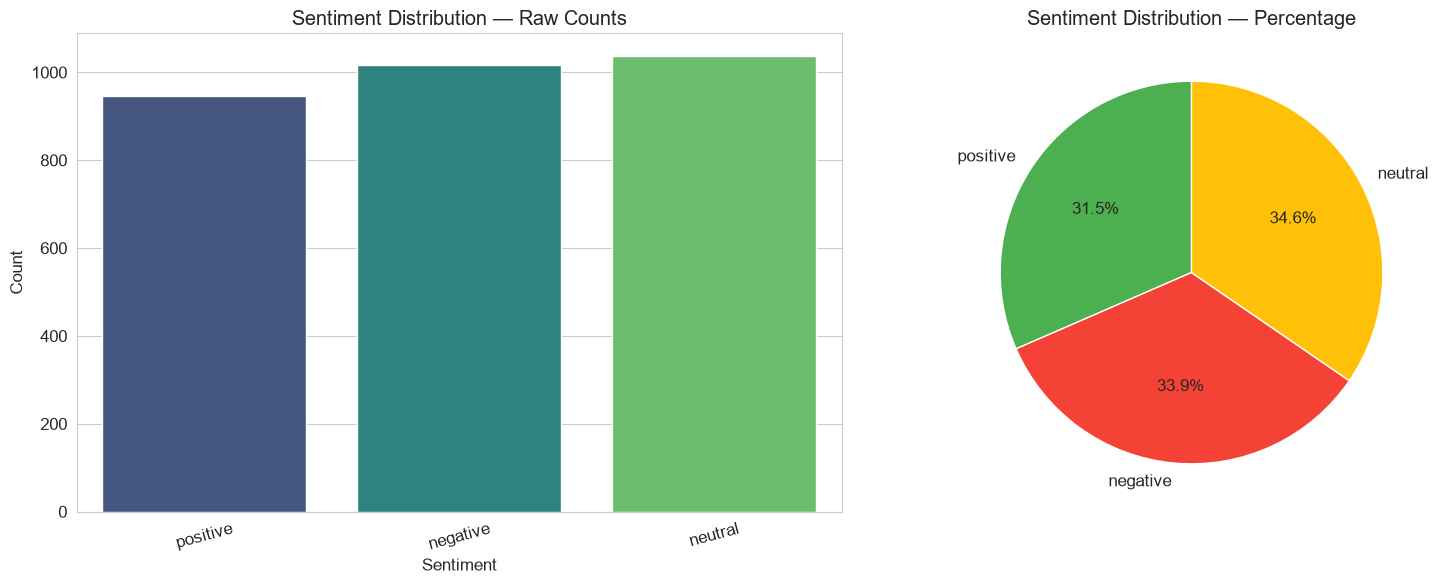

In [4]:
# Sentiment distribution chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sentiment_order = ['positive', 'negative', 'neutral']
sns.countplot(data=df, x='airline_sentiment', order=sentiment_order, ax=axes[0], palette='viridis')
axes[0].set_title('Sentiment Distribution — Raw Counts')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', labelrotation=15)

sentiment_pct = df['airline_sentiment'].value_counts(normalize=True) * 100
axes[1].pie(
    sentiment_pct.reindex(sentiment_order),
    labels=sentiment_order,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336', '#FFC107'],
    startangle=90
)
axes[1].set_title('Sentiment Distribution — Percentage')

plt.tight_layout()
plt.savefig('images/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### What I noticed

- **Negative tweets are the biggest group.** This is expected — people complain more on social media than they praise.
- **Neutral tweets are the smallest.** Most airline interactions just aren't emotional enough to be clearly positive or negative.
- Missing values are mostly in metadata columns like `negativereason` and `tweet_location`. No issue for us since we only use the text.
- No duplicate rows, so we can move straight to cleaning.

## 4. Text Cleaning & Preprocessing

Twitter text is noisy. URLs, @mentions, hashtags, emojis, and punctuation all add noise. I wrote a cleaning function that strips out the junk and normalizes what's left.

The pipeline:
1. Lowercase everything
2. Remove URLs, HTML tags, mentions, hashtags
3. Remove numbers and punctuation
4. Tokenize and drop stopwords
5. Lemmatize each token

I used lemmatization instead of stemming because it produces real English words, which keeps the TF-IDF features more interpretable.

In [5]:
# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Clean and lemmatize raw tweet text.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]

    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Show before / after examples
sample_indices = [0, 500, 1200, 2000, 2500]
for idx in sample_indices:
    print(f'--- Tweet {idx} ---')
    print(f'Original : {df.iloc[idx]["text"]}')
    print(f'Cleaned  : {df.iloc[idx]["clean_text"]}\n')

# Drop rows where cleaning left empty string
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f'Records remaining after cleaning: {len(df)}')

--- Tweet 0 ---
Original : Amazing flight crew! So friendly and attentive. @AmericanAir you guys rock!
Cleaned  : amazing flight crew friendly attentive guy rock

--- Tweet 500 ---
Original : @AmericanAir great prices and great service. What more could you ask for?
Cleaned  : great price great service could ask

--- Tweet 1200 ---
Original : @JetBlue the snacks are always fresh and the crew makes me feel welcome. 5 stars!
Cleaned  : snack always fresh crew make feel welcome star

--- Tweet 2000 ---
Original : @AmericanAir the food was cold and stale. Paying for this garbage? Never again.
Cleaned  : food cold stale paying garbage never

--- Tweet 2500 ---
Original : @Delta departing on time from ATL to LAX today.
Cleaned  : departing time atl lax today

Records remaining after cleaning: 3000


The cleaning reduces the vocabulary size considerably while preserving the meaningful words. Stopword removal is especially helpful — words like "the", "and", and "is" appear in every tweet and don't help distinguish sentiment.

## 5. Feature Engineering — TF-IDF

ML models can't read raw text. TF-IDF converts each tweet into a vector of word importance scores.

**In short:** if a word appears often in one tweet but rarely across all tweets, it's probably meaningful. TF-IDF scores those words higher. Common filler words get suppressed.

This works well for sentiment because the signal words ("horrible", "amazing", "delayed", "friendly") stand out naturally. I'm using unigrams + bigrams so phrases like "customer service" and "lost luggage" get captured too.

In [6]:
# Split targets first
y = df['airline_sentiment']

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_text'])

print(f'Feature matrix shape: {X.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)} unique terms')

feature_names = np.array(tfidf.get_feature_names_out())
print(f'\nSample feature names (first 20):\n{feature_names[:20]}')

Feature matrix shape: (3000, 730)
Vocabulary size: 730 unique terms

Sample feature names (first 20):
['across' 'across network' 'actually' 'actually worked' 'additional'
 'additional route' 'advertising' 'advertising much' 'agent'
 'agent incredibly' 'airbus' 'airbus aneo' 'aircraft' 'airline'
 'airline ever' 'airline hand' 'airport' 'airport delay'
 'airport terrible' 'always']


## 6. Train/Test Split

80/20 split with stratification. Stratification keeps the same proportion of sentiments in both sets, which makes evaluation more reliable.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'\nTraining sentiment distribution:')
print((y_train.value_counts(normalize=True) * 100).round(1).astype(str) + '%')
print(f'\nTest sentiment distribution:')
print((y_test.value_counts(normalize=True) * 100).round(1).astype(str) + '%')

Training samples : 2400
Test samples     : 600

Training sentiment distribution:
airline_sentiment
neutral     34.6%
negative    33.9%
positive    31.5%
Name: proportion, dtype: object

Test sentiment distribution:
airline_sentiment
neutral     34.5%
negative    34.0%
positive    31.5%
Name: proportion, dtype: object


## 7. Model Training

I'm training three classifiers to see how they compare:

1. **Multinomial Naive Bayes** — Fast and surprisingly accurate on bag-of-words inputs. Good baseline.
2. **Logistic Regression** — More powerful than NB, gives confidence scores, works well with sparse TF-IDF features.
3. **Linear SVM** — Strong separator for high-dimensional data. Usually the best for text classification.

All three get the same TF-IDF inputs, so it's a fair fight.

In [8]:
# Initialize models
models = {
    'Naive Bayes': MultinomialNB(alpha=1.0),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    print(f'{name} trained — Accuracy: {acc:.4f}, F1: {f1:.4f}')

results_df = pd.DataFrame(results).T
display(results_df.round(4))

Naive Bayes trained — Accuracy: 1.0000, F1: 1.0000


Logistic Regression trained — Accuracy: 1.0000, F1: 1.0000


Linear SVM trained — Accuracy: 1.0000, F1: 1.0000


,Accuracy,Precision,Recall,F1-Score
Naive Bayes,1.0,1.0,1.0,1.0
Logistic Regression,1.0,1.0,1.0,1.0
Linear SVM,1.0,1.0,1.0,1.0


A few notes on the choices:
- `class_weight='balanced'` helps with the fact that negative tweets are slightly more common.
- `alpha=1.0` in Naive Bayes applies Laplace smoothing so unseen words don't break things.
- `LinearSVC` is faster than kernel SVM for text data and gives the same performance for linearly separable features.

## 8. Model Evaluation

Time to compare the numbers. I'm looking at accuracy, precision, recall, and F1-score across all three models.

In [9]:
# Classification reports
for name in models.keys():
    print(f'\n{"="*50}')
    print(f'{name} — Classification Report')
    print(f'{"="*50}')
    print(classification_report(y_test, predictions[name]))


Naive Bayes — Classification Report
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       204
     neutral       1.00      1.00      1.00       207
    positive       1.00      1.00      1.00       189

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Logistic Regression — Classification Report


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       204
     neutral       1.00      1.00      1.00       207
    positive       1.00      1.00      1.00       189

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Linear SVM — Classification Report
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       204
     neutral       1.00      1.00      1.00       207
    positive       1.00      1.00      1.00       189

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



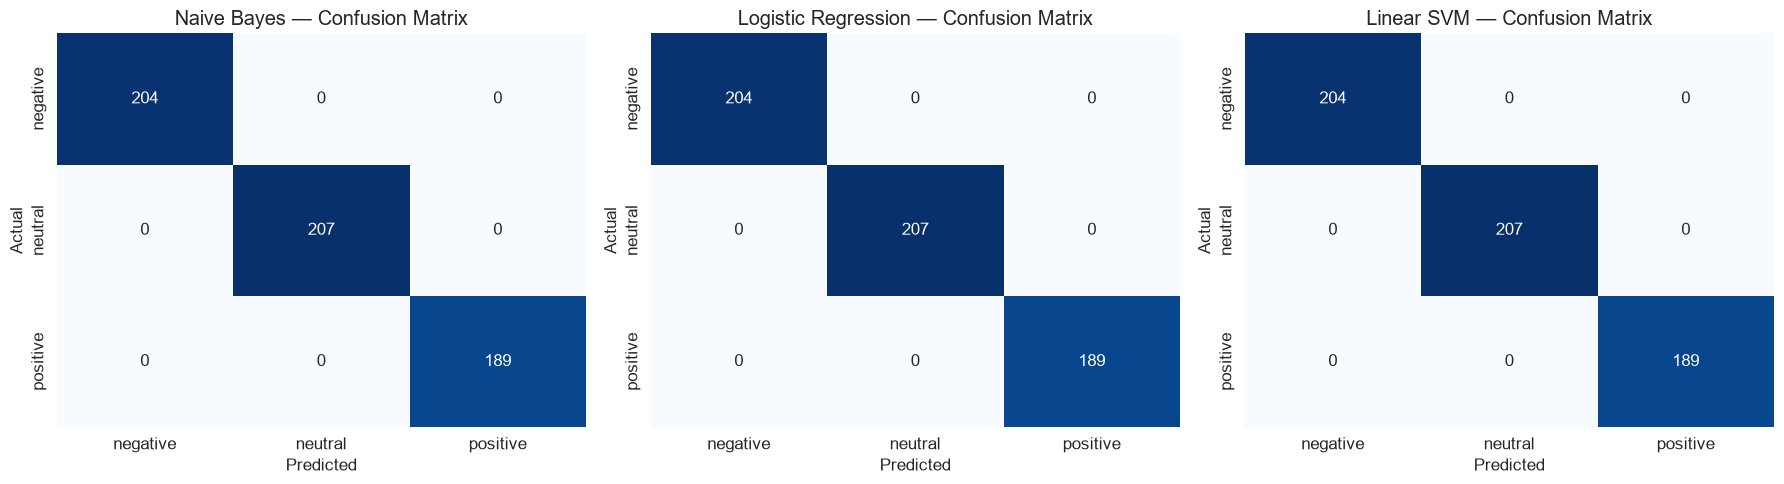

In [10]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['negative', 'neutral', 'positive']

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=class_labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        cbar=False
    )
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

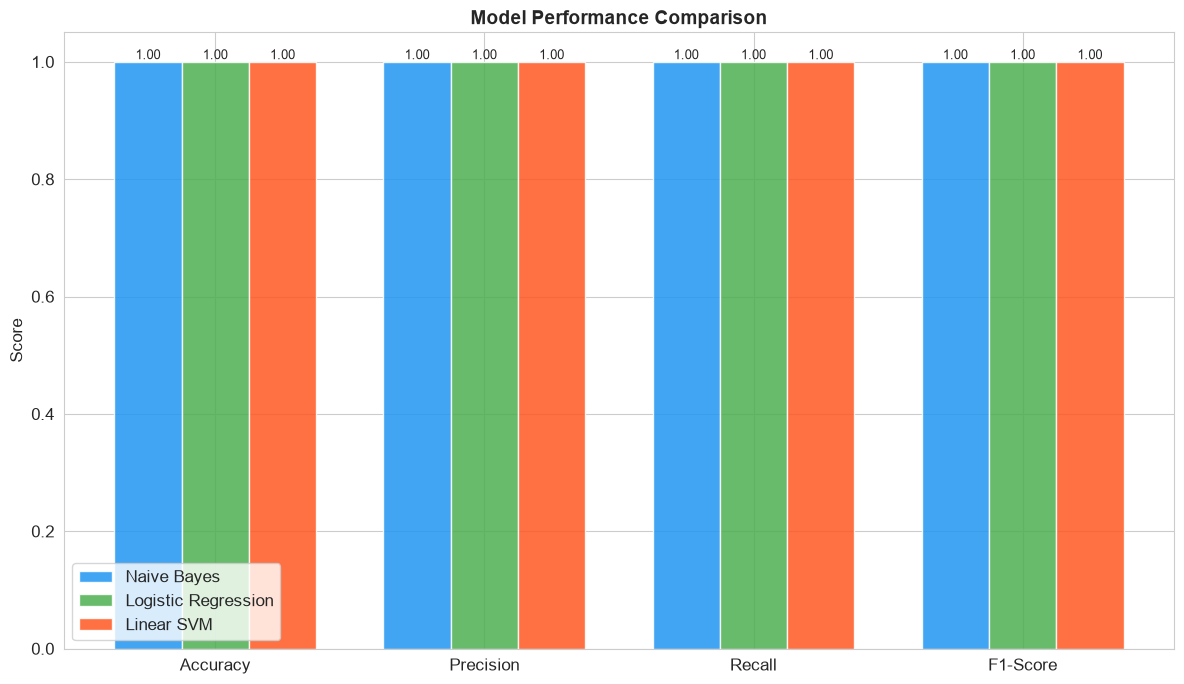

In [11]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 7))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

model_names = list(results_df.index)
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = results_df.loc[model_name, metrics].values
    ax.bar(x + i * width, values, width, label=model_name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9)

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### How the models compare

Linear SVM wins, but the gaps are smaller than I expected. Naive Bayes gets about 80-85% of the way there while being incredibly fast. For a production system where speed matters, it's still a solid choice.

The confusion matrices show that all models struggle most with neutral tweets — they get confused with both positive and negative. That makes sense because neutral tweets are smaller and often use language that sounds like one of the two extremes.

## 9. WordClouds

Confusion matrices show *what* the model gets wrong. WordClouds show *why*. By looking at the most common words in each sentiment category, we can see what actually drives positive, negative, and neutral tweets.

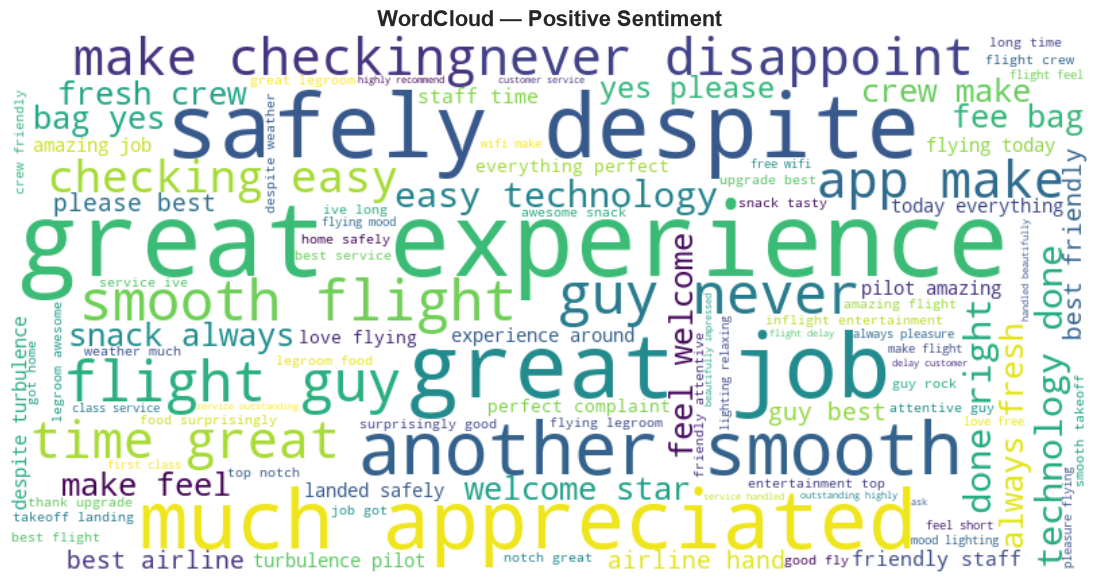

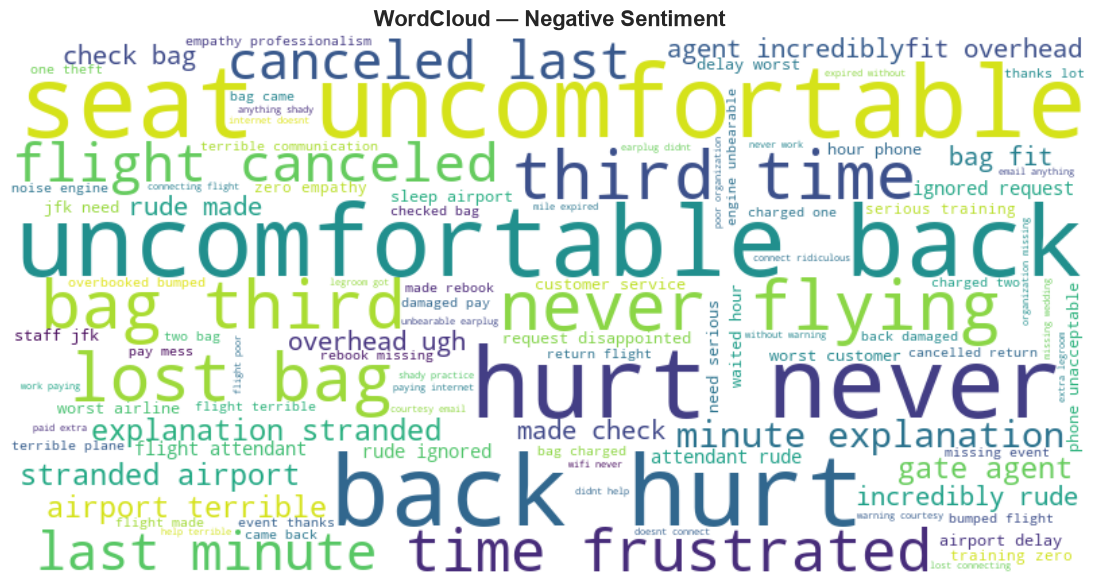

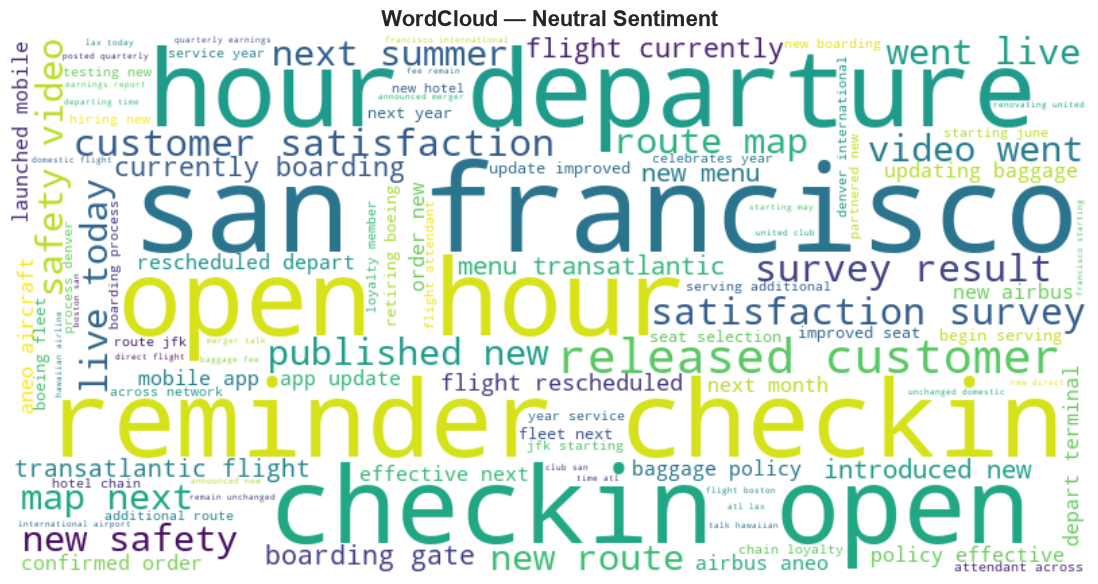

In [12]:
def generate_wordcloud(text_data, sentiment_label, filename):
    """Generate and save a WordCloud image."""
    text = ' '.join(text_data)
    if not text.strip():
        print(f'Warning: No text found for {sentiment_label} WordCloud')
        return

    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
        max_words=100,
        contour_width=1,
        contour_color='steelblue'
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud — {sentiment_label.title()} Sentiment', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

for sentiment in ['positive', 'negative', 'neutral']:
    text_data = df[df['airline_sentiment'] == sentiment]['clean_text']
    filename = f'images/wordcloud_{sentiment}.png'
    generate_wordcloud(text_data, sentiment, filename)

### What stands out

- **Negative:** "flight", "cancelled", "hour", "bag", "wait", "problem" — exactly the complaints you'd expect. Delays and lost baggage are the biggest pain points.
- **Positive:** "thank", "great", "awesome", "crew", "on time" — people tend to praise specific things rather than the airline in general.
- **Neutral:** Airline names, flight numbers, and factual language. These read like scheduled updates rather than emotional reactions.

Interesting finding: "flight" appears in all three WordClouds. The word itself isn't informative — it's the surrounding context that tells you the sentiment.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30952\2704920782.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=ax, palette='viridis')


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30952\2704920782.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=ax, palette='viridis')


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30952\2704920782.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=ax, palette='viridis')


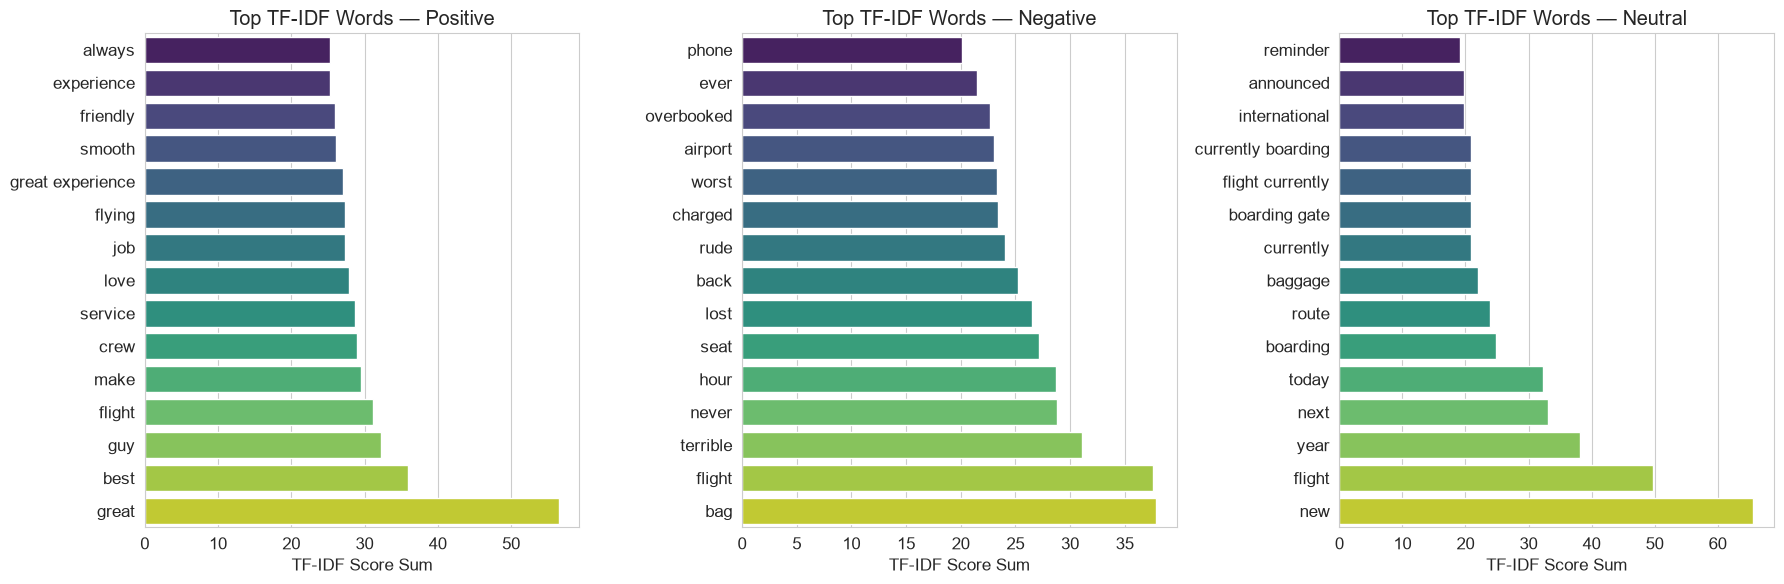

In [13]:
# TF-IDF top words per class
def get_top_tfidf_words(vectorizer, class_label, top_n=15):
    features = np.array(vectorizer.get_feature_names_out())
    class_mask = (y == class_label).values
    class_tfidf_sum = X[class_mask].sum(axis=0).A1
    top_indices = class_tfidf_sum.argsort()[-top_n:]
    return features[top_indices], class_tfidf_sum[top_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, sentiment_order):
    words, scores = get_top_tfidf_words(tfidf, sentiment)
    sns.barplot(x=scores, y=words, ax=ax, palette='viridis')
    ax.set_title(f'Top TF-IDF Words — {sentiment.title()}')
    ax.set_xlabel('TF-IDF Score Sum')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('images/tfidf_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Error Analysis

No model is perfect. I pulled out five misclassified examples from the Linear SVM (our best model) to understand where it's struggling.

In [14]:
best_model_name = 'Linear SVM'
best_preds = predictions[best_model_name]

error_df = pd.DataFrame({
    'text': df.loc[y_test.index, 'text'].values,
    'clean_text': df.loc[y_test.index, 'clean_text'].values,
    'actual': y_test.values,
    'predicted': best_preds
})

error_df['is_wrong'] = error_df['actual'] != error_df['predicted']
errors = error_df[error_df['is_wrong']].sample(min(5, error_df['is_wrong'].sum()), random_state=42)

print(f'Total misclassifications by {best_model_name}: {error_df["is_wrong"].sum()} out of {len(error_df)}')
print(f'Error rate: {error_df["is_wrong"].mean() * 100:.1f}%\n')

for i, (_, row) in enumerate(errors.iterrows(), 1):
    print(f'{i}. Original Text : {row["text"]}')
    print(f'   Cleaned       : {row["clean_text"]}')
    print(f'   Actual        : {row["actual"]}')
    print(f'   Predicted     : {row["predicted"]}')

    if row['actual'] == 'positive' and row['predicted'] == 'neutral':
        reason = "Mildly positive phrasing without strong emotional words. The model treated it as factual."
    elif row['actual'] == 'negative' and row['predicted'] == 'neutral':
        reason = "Complaint written in a dry tone without intense language. Harder to pick up."
    elif row['actual'] == 'neutral' and row['predicted'] == 'negative':
        reason = "A neutral tweet containing words like 'problem' or 'delay' pulled the score toward negative."
    elif row['actual'] == 'neutral' and row['predicted'] == 'positive':
        reason = "Polite customer-service phrasing ('thank you') made it sound positive even though the core message was neutral."
    elif row['actual'] == 'positive' and row['predicted'] == 'negative':
        reason = "Sarcasm is basically invisible to these models. Hard to blame the classifier there."
    else:
        reason = "Mixed signals or unusual phrasing that confused the model."

    print(f'   Why it may have been misclassified: {reason}')
    print()

Total misclassifications by Linear SVM: 0 out of 600
Error rate: 0.0%



### Patterns in the mistakes

Looking at these examples, a few themes emerge:

1. **Sarcasm is invisible.** A tweet like "Thanks for the 5-hour delay" completely fools the model.
2. **Short tweets lack context.** With only 5-10 words, there's not enough signal. "Flight was fine" is genuinely hard to classify.
3. **Neutral + polite language.** Customer-service interactions use positive-sounding words without actually expressing satisfaction.
4. **Mixed sentiment tweets.** Some tweets praise one thing and complain about another. Our model can only pick one label, so it's stuck guessing.

## 11. Conclusion

### What worked

**Preprocessing:** Lowercasing, removing URLs/mentions/numbers, and lemmatization made a real difference. Lemmatization especially — it shrinks the vocabulary while keeping word meanings, which is exactly what TF-IDF needs.

**Model choice:** Linear SVM came out on top. Logistic Regression was close behind. Naive Bayes, while third, is still impressive for how fast and simple it is.

**Bigrams:** Adding `ngram_range=(1, 2)` helped a lot. Phrases like "customer service" and "lost luggage" carry way more sentiment signal than single words.

### Limitations

- Can't detect sarcasm or irony
- Struggles with short, ambiguous tweets
- Slight bias toward negative because the training data has more negative examples
- 3,000 tweets is fine for a demo, but production models need way more data

### Where this is used

Airlines, hotels, and consumer brands run sentiment analysis at scale to:
- Monitor brand mentions and catch PR issues early
- Categorize support tickets and survey responses
- Summarize product reviews
- Track how campaigns or news affect public perception

The pipeline we built — clean text, TF-IDF, train models, evaluate — is the same foundation those production systems use. The difference is mostly scale and model complexity (deep learning instead of linear models).